# Euclidean Scenario Experiment Analysis

This notebook analyzes the resit experiment artifacts directly with pandas and matplotlib. It does not use `analysis/compare_results.py`.

Artifact inputs are auto-detected from `analysis/github_artifacts/*-ga/` and `analysis/github_artifacts/*-greedy/`. After running the corrected workflows, download the new artifacts into that directory and rerun the notebook.

The Genetic Algorithm is summarized as an average-of-3 seed summary: all three seeds are included for each problem instance, and no best seed is selected.

In [13]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Configuration

The corrected resit experiment uses two travel budgets: `2500` and `7500`. The report-style figures below use these as the lower and higher travel budgets.

In [14]:
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
ARTIFACTS_ROOT = REPO_ROOT / 'analysis' / 'github_artifacts'
GA_ROOTS = sorted(ARTIFACTS_ROOT.glob('*-ga'))
GREEDY_ROOTS = sorted(ARTIFACTS_ROOT.glob('*-greedy'))
OUTPUT_DIR = REPO_ROOT / 'analysis' / 'output' / 'euclidean_resit_plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOWER_BUDGET = 2500
HIGHER_BUDGET = 7500
REPORT_BUDGETS = [LOWER_BUDGET, HIGHER_BUDGET]

SCENARIO_CLASSES = {
    'Baseline Distribution': [
        'uniform_random_depot',
        'uniform_center_depot',
        'uniform_corner_depot',
    ],
    'Clustered Structure': [
        'clustered_center_depot',
        'clustered_offset_depot',
        'clustered_outliers',
    ],
    'Geometric Layout': [
        'corridor',
        'ring',
    ],
    'Reward Structure': [
        'reward_near_depot',
        'reward_far_from_depot',
        'reward_cluster_hotspot',
    ],
}

SCENARIO_LABELS = {
    'uniform_random_depot': 'random depot',
    'uniform_center_depot': 'center depot',
    'uniform_corner_depot': 'corner depot',
    'clustered_center_depot': 'clustered center',
    'clustered_offset_depot': 'clustered offset',
    'clustered_outliers': 'clustered outliers',
    'corridor': 'corridor',
    'ring': 'ring',
    'reward_near_depot': 'near-depot reward',
    'reward_far_from_depot': 'far-depot reward',
    'reward_cluster_hotspot': 'cluster hotspot',
}

SCENARIO_TO_CLASS = {scenario: cls for cls, scenarios in SCENARIO_CLASSES.items() for scenario in scenarios}
SCENARIO_ORDER = {scenario: i for scenarios in SCENARIO_CLASSES.values() for i, scenario in enumerate(scenarios)}
CLASS_ORDER = {cls: i for i, cls in enumerate(SCENARIO_CLASSES)}
APPROACH_ORDER = {'Greedy Baseline': 0, 'Genetic Algorithm': 1}
COLORS = {'Greedy Baseline': '#4C78A8', 'Genetic Algorithm': '#F58518'}


## Load Artifacts

Each solution file stores collected reward and travel cost on the first line. Runtime is read from the matching metadata JSON file.

In [15]:
GA_RUN_RE = re.compile(r'euclidean_scenarios_(?P<scenario>.+?)_ga_budget(?P<budget>\d+)_seed(?P<seed>\d+)_g')
GREEDY_RUN_RE = re.compile(r'euclidean_scenarios_(?P<scenario>.+?)_(?P<budget>\d+)$')

def read_solution(path: Path) -> tuple[int, int]:
    first_line = path.read_text(encoding='utf-8').splitlines()[0]
    reward_text, cost_text = first_line.split()[:2]
    return int(reward_text), int(cost_text)

def metadata_path(solution_path: Path, metadata_kind: str) -> Path:
    artifact_dir = solution_path.parents[2]
    run_dir = solution_path.parent.name
    return artifact_dir / 'results_metadata' / metadata_kind / run_dir / solution_path.name.replace('.txt', '.json')

def read_runtime(path: Path) -> float | None:
    if not path.exists():
        return None
    with path.open(encoding='utf-8') as handle:
        metadata = json.load(handle)
    return metadata.get('runtime_seconds')

def parse_result_files(roots: list[Path], approach: str) -> pd.DataFrame:
    rows = []
    if approach == 'ga':
        run_re = GA_RUN_RE
        metadata_kind = 'genetic'
        approach_label = 'Genetic Algorithm'
    else:
        run_re = GREEDY_RUN_RE
        metadata_kind = 'greedy'
        approach_label = 'Greedy Baseline'

    for root in roots:
        for solution_path in root.glob('**/results/euclidean_scenarios_*/graph_*.txt'):
            run_dir = solution_path.parent.name
            match = run_re.match(run_dir)
            if not match:
                continue
            scenario = match.group('scenario')
            if scenario not in SCENARIO_TO_CLASS:
                continue
            budget = int(match.group('budget'))
            if budget not in REPORT_BUDGETS:
                continue
            seed = int(match.groupdict().get('seed') or 0)
            reward, cost = read_solution(solution_path)
            rows.append({
                'artifact_root': root.name,
                'approach': approach,
                'approach_label': approach_label,
                'scenario': scenario,
                'scenario_label': SCENARIO_LABELS[scenario],
                'scenario_class': SCENARIO_TO_CLASS[scenario],
                'class_order': CLASS_ORDER[SCENARIO_TO_CLASS[scenario]],
                'scenario_order': SCENARIO_ORDER[scenario],
                'budget': budget,
                'seed': seed,
                'graph': solution_path.name,
                'reward': reward,
                'cost': cost,
                'runtime_seconds': read_runtime(metadata_path(solution_path, metadata_kind)),
                'solution_path': solution_path.relative_to(REPO_ROOT).as_posix(),
            })
    return pd.DataFrame(rows)

raw = pd.concat([
    parse_result_files(GREEDY_ROOTS, 'greedy'),
    parse_result_files(GA_ROOTS, 'ga'),
], ignore_index=True)

dedupe_keys = ['approach', 'scenario', 'budget', 'seed', 'graph']
raw = raw.sort_values(['artifact_root']).drop_duplicates(dedupe_keys, keep='last')

raw = raw.sort_values(['approach', 'scenario_class', 'scenario_order', 'budget', 'seed', 'graph']).reset_index(drop=True)
raw.head()


,approach,approach_label,scenario,scenario_label,scenario_class,class_order,scenario_order,budget,seed,graph,reward,cost,runtime_seconds,solution_path
0,ga,Genetic Algorithm,uniform_random_depot,random depot,Baseline Distribution,0,0,50,1,graph_001.txt,0,0,0.338762,analysis/github_artifacts/30754548169-ga/ga-eu...
1,ga,Genetic Algorithm,uniform_random_depot,random depot,Baseline Distribution,0,0,50,1,graph_002.txt,0,0,0.334475,analysis/github_artifacts/30754548169-ga/ga-eu...
2,ga,Genetic Algorithm,uniform_random_depot,random depot,Baseline Distribution,0,0,50,1,graph_003.txt,0,0,0.340372,analysis/github_artifacts/30754548169-ga/ga-eu...
3,ga,Genetic Algorithm,uniform_random_depot,random depot,Baseline Distribution,0,0,50,1,graph_004.txt,0,0,0.335435,analysis/github_artifacts/30754548169-ga/ga-eu...
4,ga,Genetic Algorithm,uniform_random_depot,random depot,Baseline Distribution,0,0,50,1,graph_005.txt,0,0,0.334126,analysis/github_artifacts/30754548169-ga/ga-eu...


In [16]:
coverage = (
    raw.groupby(['approach_label', 'scenario_class', 'scenario', 'budget'])
    .agg(files=('graph', 'count'), seeds=('seed', lambda values: ','.join(map(str, sorted(set(values))))))
    .reset_index()
    .sort_values(['approach_label', 'scenario_class', 'scenario', 'budget'])
)
print(f'Raw rows: {len(raw)}')
print(f'Budgets: {sorted(raw.budget.unique())}')
coverage.head(20)


Raw rows: 880
Budgets: [np.int64(50), np.int64(100), np.int64(200), np.int64(300)]


,approach_label,scenario_class,scenario,budget,files,seeds
0,Genetic Algorithm,Baseline Distribution,uniform_center_depot,50,15,"1,2,3"
1,Genetic Algorithm,Baseline Distribution,uniform_center_depot,100,15,"1,2,3"
2,Genetic Algorithm,Baseline Distribution,uniform_center_depot,200,15,"1,2,3"
3,Genetic Algorithm,Baseline Distribution,uniform_center_depot,300,15,"1,2,3"
4,Genetic Algorithm,Baseline Distribution,uniform_corner_depot,50,15,"1,2,3"
5,Genetic Algorithm,Baseline Distribution,uniform_corner_depot,100,15,"1,2,3"
6,Genetic Algorithm,Baseline Distribution,uniform_corner_depot,200,15,"1,2,3"
7,Genetic Algorithm,Baseline Distribution,uniform_corner_depot,300,15,"1,2,3"
8,Genetic Algorithm,Baseline Distribution,uniform_random_depot,50,15,"1,2,3"
9,Genetic Algorithm,Baseline Distribution,uniform_random_depot,100,15,"1,2,3"


## Average-of-3 GA Summary

The GA is stochastic, so this notebook averages reward, cost, and runtime across all three seeds for each `(scenario, budget, graph)` case. This avoids selecting the best seed.

In [17]:
greedy_instances = raw[raw.approach == 'greedy'].copy()
ga_seed_runs = raw[raw.approach == 'ga'].copy()

ga_instances = (
    ga_seed_runs.groupby([
        'scenario', 'scenario_label', 'scenario_class', 'class_order', 'scenario_order', 'budget', 'graph'
    ], as_index=False)
    .agg(
        seed_count=('seed', 'nunique'),
        reward=('reward', 'mean'),
        cost=('cost', 'mean'),
        runtime_seconds=('runtime_seconds', 'mean'),
    )
)
ga_instances['approach'] = 'ga_average_of_3'
ga_instances['approach_label'] = 'Genetic Algorithm'

greedy_instances['seed_count'] = 1
instance_rows = pd.concat([
    greedy_instances[[
        'scenario', 'scenario_label', 'scenario_class', 'class_order', 'scenario_order',
        'budget', 'graph', 'seed_count', 'reward', 'cost', 'runtime_seconds',
        'approach', 'approach_label'
    ]],
    ga_instances[[
        'scenario', 'scenario_label', 'scenario_class', 'class_order', 'scenario_order',
        'budget', 'graph', 'seed_count', 'reward', 'cost', 'runtime_seconds',
        'approach', 'approach_label'
    ]],
], ignore_index=True)

complete_keys = (
    instance_rows.groupby(['scenario', 'budget', 'graph'])['approach_label']
    .nunique()
    .reset_index(name='approach_count')
)
complete_keys = complete_keys[complete_keys.approach_count == 2][['scenario', 'budget', 'graph']]
complete_instances = instance_rows.merge(complete_keys, on=['scenario', 'budget', 'graph'])

print(f'Complete instance rows: {len(complete_instances)}')
print(f'Complete problem-instance/budget cases: {len(complete_keys)}')
complete_instances.head()


Complete instance rows: 440
Complete problem-instance/budget cases: 220


,scenario,scenario_label,scenario_class,class_order,scenario_order,budget,graph,seed_count,reward,cost,runtime_seconds,approach,approach_label
0,uniform_random_depot,random depot,Baseline Distribution,0,0,50,graph_001.txt,1,0.0,0.0,0.019051,greedy,Greedy Baseline
1,uniform_random_depot,random depot,Baseline Distribution,0,0,50,graph_002.txt,1,0.0,0.0,0.017862,greedy,Greedy Baseline
2,uniform_random_depot,random depot,Baseline Distribution,0,0,50,graph_003.txt,1,0.0,0.0,0.017691,greedy,Greedy Baseline
3,uniform_random_depot,random depot,Baseline Distribution,0,0,50,graph_004.txt,1,0.0,0.0,0.018103,greedy,Greedy Baseline
4,uniform_random_depot,random depot,Baseline Distribution,0,0,50,graph_005.txt,1,0.0,0.0,0.017602,greedy,Greedy Baseline


## Main Figure 1 and 2: Mean Collected Reward

Caption template for the lower budget: Mean collected reward at the lower travel budget, `L_max=50`. Scenario presets are grouped by scenario class. Error bars show one standard deviation over five instances.

Caption template for the higher budget: Mean collected reward at the higher travel budget, `L_max=300`. Scenario presets are grouped by scenario class. Error bars show one standard deviation over five instances.

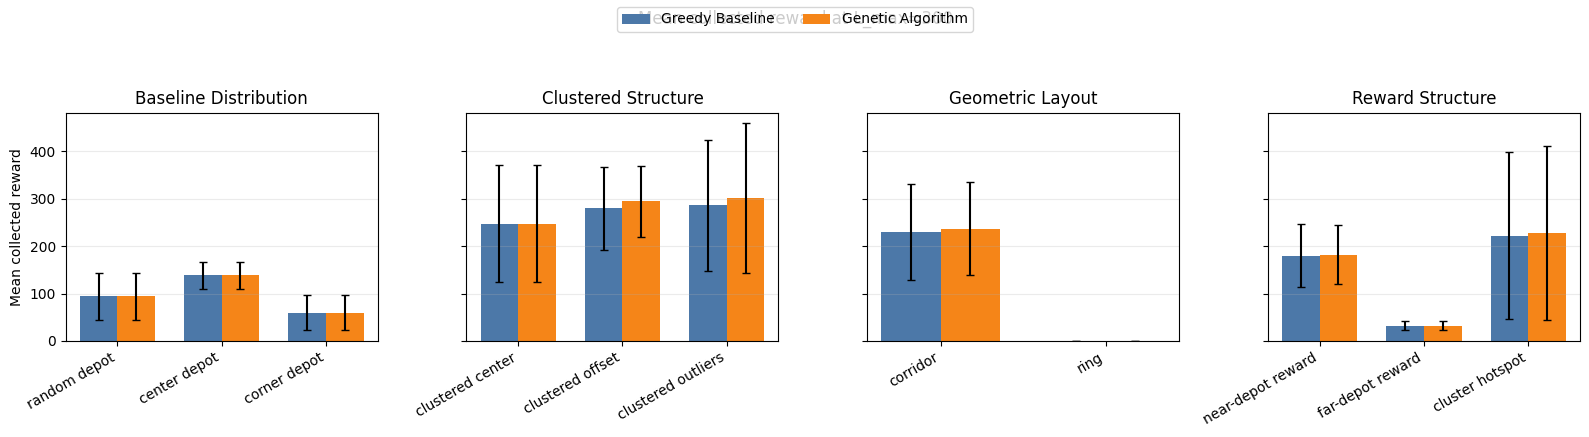

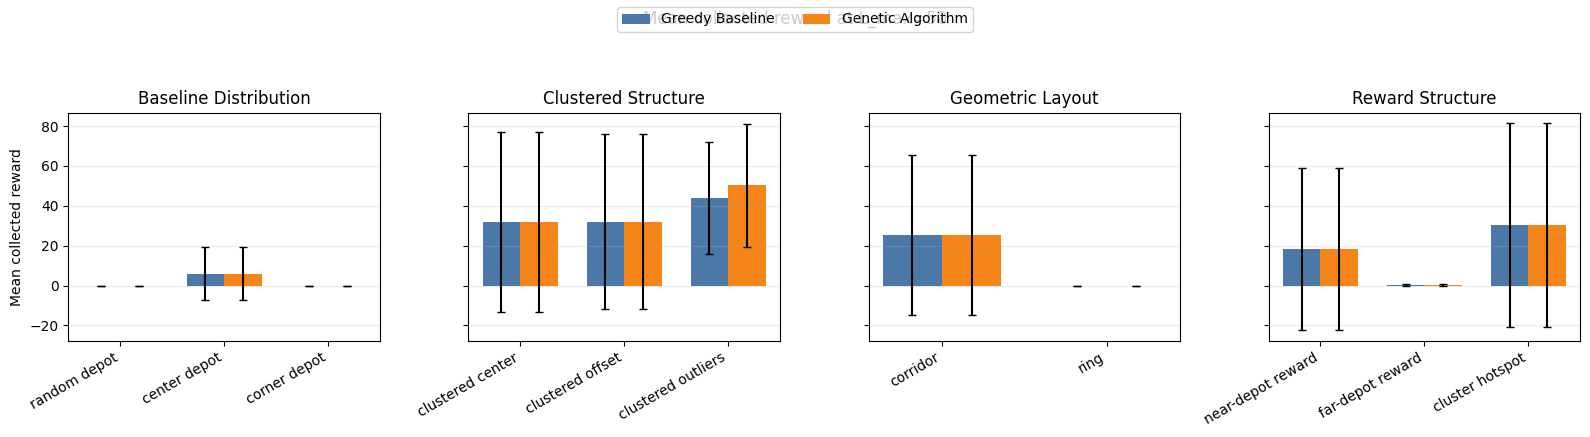

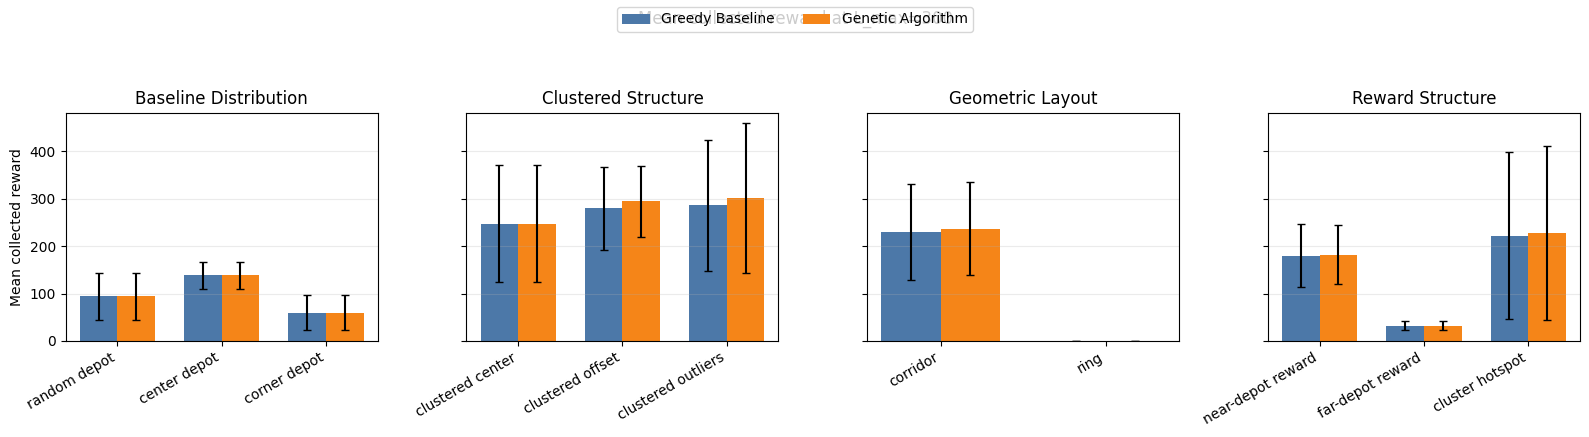

In [18]:
def preset_summary(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby([
            'budget', 'scenario_class', 'class_order', 'scenario', 'scenario_label', 'scenario_order', 'approach_label'
        ], as_index=False)
        .agg(
            instances=('graph', 'nunique'),
            mean_reward=('reward', 'mean'),
            std_reward=('reward', 'std'),
            mean_cost=('cost', 'mean'),
            mean_runtime_seconds=('runtime_seconds', 'mean'),
        )
        .sort_values(['budget', 'class_order', 'scenario_order', 'approach_label'])
    )

per_preset = preset_summary(complete_instances)

def plot_reward_by_budget(budget: int):
    data = per_preset[per_preset.budget == budget]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for axis, (scenario_class, scenarios) in zip(axes, SCENARIO_CLASSES.items()):
        class_data = data[data.scenario_class == scenario_class]
        labels = [SCENARIO_LABELS[scenario] for scenario in scenarios]
        x = np.arange(len(scenarios))
        width = 0.36
        for offset, approach in [(-width / 2, 'Greedy Baseline'), (width / 2, 'Genetic Algorithm')]:
            approach_data = class_data[class_data.approach_label == approach].set_index('scenario')
            means = [approach_data.loc[scenario, 'mean_reward'] for scenario in scenarios]
            stds = [approach_data.loc[scenario, 'std_reward'] for scenario in scenarios]
            axis.bar(x + offset, means, width, yerr=stds, label=approach, color=COLORS[approach], capsize=3)
        axis.set_title(scenario_class)
        axis.set_xticks(x)
        axis.set_xticklabels(labels, rotation=30, ha='right')
        axis.grid(axis='y', alpha=0.25)
    axes[0].set_ylabel('Mean collected reward')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    fig.suptitle(f'Mean collected reward at L_max={budget}', y=1.08)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'mean_collected_reward_budget_{budget}.png', dpi=200, bbox_inches='tight')
    return fig

plot_reward_by_budget(LOWER_BUDGET)
plot_reward_by_budget(HIGHER_BUDGET)


## Main Figure 3: Reward Difference

Caption: Mean reward difference, computed as Genetic Algorithm reward minus Greedy Baseline reward. Positive values indicate higher Genetic Algorithm reward. Scenario presets are grouped by scenario class.

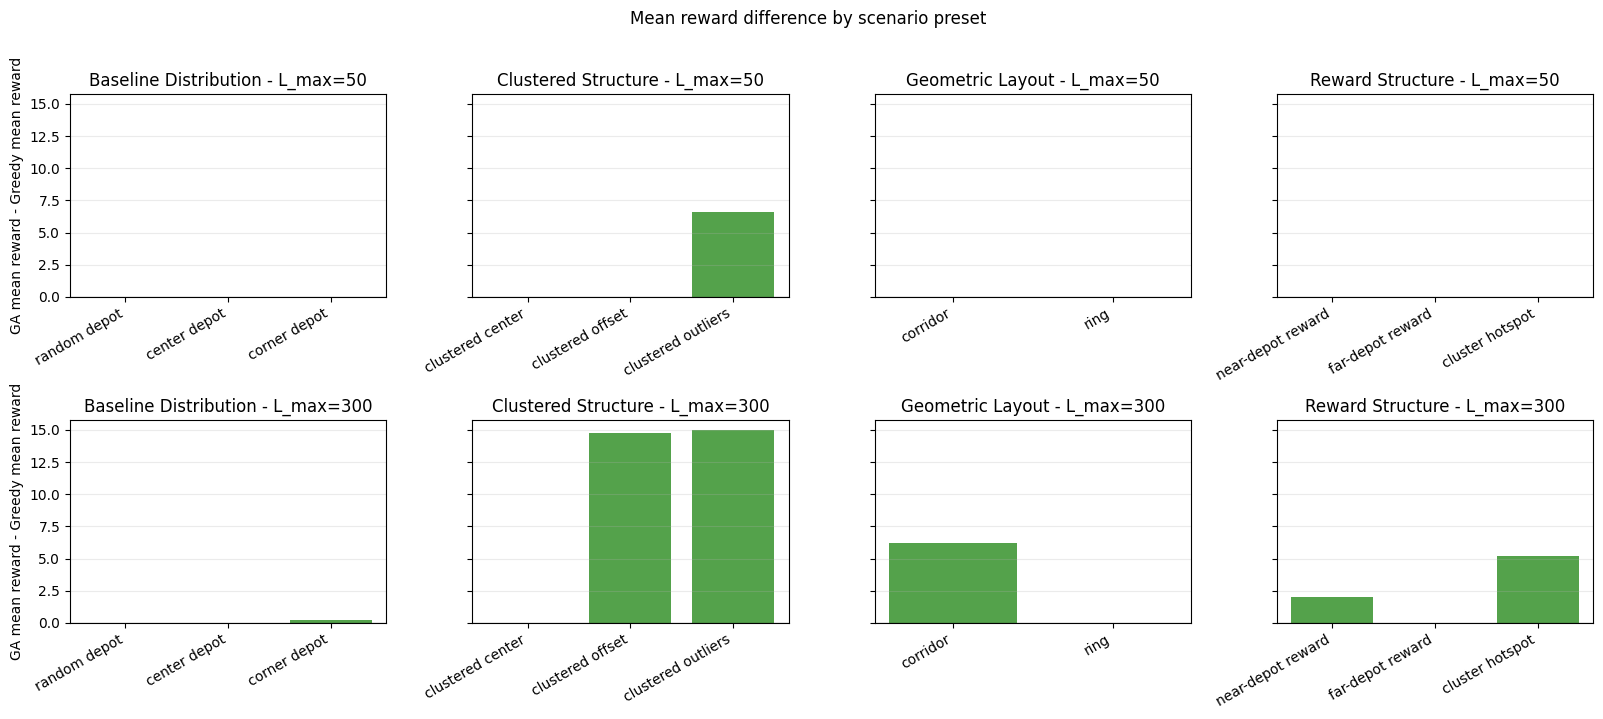

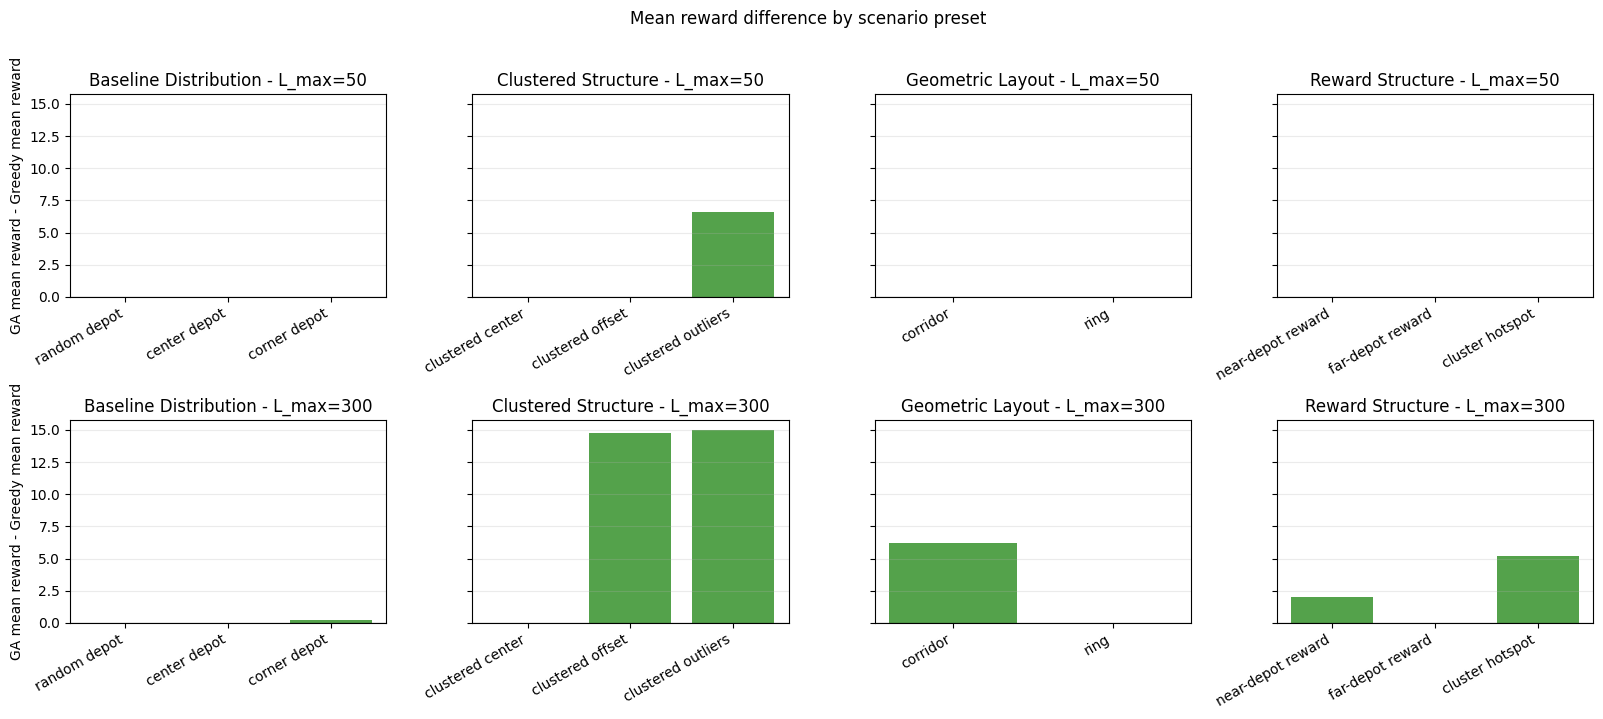

In [19]:
def reward_difference_table(frame: pd.DataFrame) -> pd.DataFrame:
    paired = frame.pivot_table(
        index=['scenario', 'scenario_label', 'scenario_class', 'class_order', 'scenario_order', 'budget', 'graph'],
        columns='approach_label',
        values='reward',
        aggfunc='mean',
    ).reset_index()
    paired['reward_difference'] = paired['Genetic Algorithm'] - paired['Greedy Baseline']
    return (
        paired.groupby(['budget', 'scenario_class', 'class_order', 'scenario', 'scenario_label', 'scenario_order'], as_index=False)
        .agg(mean_reward_difference=('reward_difference', 'mean'))
        .sort_values(['budget', 'class_order', 'scenario_order'])
    )

reward_diff = reward_difference_table(complete_instances)

def plot_reward_difference(budgets: list[int]):
    fig, axes = plt.subplots(len(budgets), 4, figsize=(16, 3.5 * len(budgets)), sharey=True)
    axes = np.atleast_2d(axes)
    for row_index, budget in enumerate(budgets):
        data = reward_diff[reward_diff.budget == budget]
        for col_index, (scenario_class, scenarios) in enumerate(SCENARIO_CLASSES.items()):
            axis = axes[row_index, col_index]
            class_data = data[data.scenario_class == scenario_class].set_index('scenario')
            labels = [SCENARIO_LABELS[scenario] for scenario in scenarios]
            values = [class_data.loc[scenario, 'mean_reward_difference'] for scenario in scenarios]
            colors = ['#54A24B' if value >= 0 else '#E45756' for value in values]
            x = np.arange(len(scenarios))
            axis.bar(x, values, color=colors)
            axis.axhline(0, color='black', linewidth=0.8)
            axis.set_title(f'{scenario_class} - L_max={budget}')
            axis.set_xticks(x)
            axis.set_xticklabels(labels, rotation=30, ha='right')
            axis.grid(axis='y', alpha=0.25)
    for axis in axes[:, 0]:
        axis.set_ylabel('GA mean reward - Greedy mean reward')
    fig.suptitle('Mean reward difference by scenario preset', y=1.02)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'mean_reward_difference_lower_higher_budget.png', dpi=200, bbox_inches='tight')
    return fig

plot_reward_difference(REPORT_BUDGETS)


## Main Figure 4: Runtime Trade-Off

Caption: Mean per-instance runtime for each approach at both travel budgets. The vertical axis uses a logarithmic scale because the Genetic Algorithm is substantially slower than the Greedy Baseline.

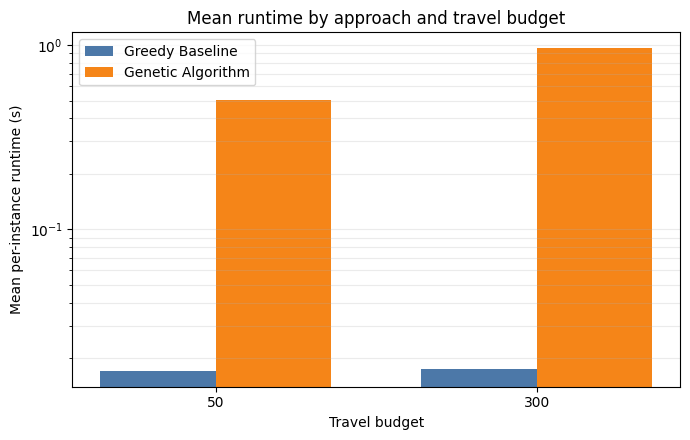

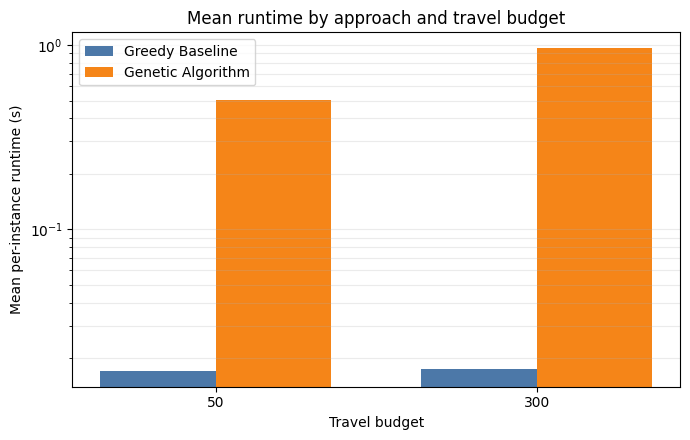

In [20]:
runtime_summary = (
    complete_instances[complete_instances.budget.isin(REPORT_BUDGETS)]
    .groupby(['budget', 'approach_label'], as_index=False)
    .agg(mean_runtime_seconds=('runtime_seconds', 'mean'), instances=('graph', 'count'))
    .sort_values(['budget', 'approach_label'])
)

fig, axis = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(REPORT_BUDGETS))
width = 0.36
for offset, approach in [(-width / 2, 'Greedy Baseline'), (width / 2, 'Genetic Algorithm')]:
    data = runtime_summary[runtime_summary.approach_label == approach].set_index('budget')
    values = [data.loc[budget, 'mean_runtime_seconds'] for budget in REPORT_BUDGETS]
    axis.bar(x + offset, values, width, label=approach, color=COLORS[approach])
axis.set_xticks(x)
axis.set_xticklabels([str(budget) for budget in REPORT_BUDGETS])
axis.set_xlabel('Travel budget')
axis.set_ylabel('Mean per-instance runtime (s)')
axis.set_yscale('log')
axis.set_title('Mean runtime by approach and travel budget')
axis.grid(axis='y', which='both', alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mean_runtime_by_approach_and_budget.png', dpi=200, bbox_inches='tight')
fig


## Appendix Tables

These tables give exact values behind the plots. They are useful for appendix material and for checking that the figures are not hiding missing data.

In [21]:
aggregate_table = (
    complete_instances.groupby(['budget', 'approach_label'], as_index=False)
    .agg(
        valid_instance_rows=('graph', 'count'),
        problem_instances=('graph', 'nunique'),
        mean_collected_reward=('reward', 'mean'),
        mean_travel_cost=('cost', 'mean'),
        mean_runtime_seconds=('runtime_seconds', 'mean'),
    )
    .sort_values(['budget', 'approach_label'])
)
aggregate_table.to_csv(OUTPUT_DIR / 'appendix_aggregate_table.csv', index=False)
aggregate_table


,budget,approach_label,valid_instance_rows,problem_instances,mean_collected_reward,mean_travel_cost,mean_runtime_seconds
0,50,Genetic Algorithm,55,5,17.672727,10.000000,0.505344
1,50,Greedy Baseline,55,5,17.072727,9.527273,0.017137
2,100,Genetic Algorithm,55,5,52.236364,45.436364,0.579509
3,100,Greedy Baseline,55,5,51.472727,44.090909,0.017629
4,200,Genetic Algorithm,55,5,104.709091,124.818182,0.740941
5,200,Greedy Baseline,55,5,103.254545,122.690909,0.017935
6,300,Genetic Algorithm,55,5,164.872727,234.254545,0.958381
7,300,Greedy Baseline,55,5,160.927273,227.781818,0.017510


In [22]:
per_preset_table = per_preset[[
    'budget', 'scenario_class', 'scenario_label', 'approach_label', 'instances',
    'mean_reward', 'std_reward', 'mean_cost', 'mean_runtime_seconds'
]].copy()
per_preset_table.to_csv(OUTPUT_DIR / 'appendix_per_preset_table.csv', index=False)
per_preset_table.head(30)


,budget,scenario_class,scenario_label,approach_label,instances,mean_reward,std_reward,mean_cost,mean_runtime_seconds
4,50,Baseline Distribution,random depot,Genetic Algorithm,5,0.0,0.000000,0.0,0.435730
5,50,Baseline Distribution,random depot,Greedy Baseline,5,0.0,0.000000,0.0,0.018062
0,50,Baseline Distribution,center depot,Genetic Algorithm,5,6.0,13.416408,3.2,0.513683
1,50,Baseline Distribution,center depot,Greedy Baseline,5,6.0,13.416408,3.2,0.017706
2,50,Baseline Distribution,corner depot,Genetic Algorithm,5,0.0,0.000000,0.0,0.474001
3,50,Baseline Distribution,corner depot,Greedy Baseline,5,0.0,0.000000,0.0,0.017641
6,50,Clustered Structure,clustered center,Genetic Algorithm,5,31.8,45.268090,19.6,0.521662
7,50,Clustered Structure,clustered center,Greedy Baseline,5,31.8,45.268090,19.6,0.017927
8,50,Clustered Structure,clustered offset,Genetic Algorithm,5,32.0,43.869124,16.4,0.537593
9,50,Clustered Structure,clustered offset,Greedy Baseline,5,32.0,43.869124,16.4,0.017894


## GA Seed Reliability

This table checks the stability of the three GA seeds. It is grouped by travel budget and scenario class, matching the diagnostic scenario-class structure.

In [23]:
seed_case = (
    ga_seed_runs.groupby(['budget', 'scenario_class', 'class_order', 'scenario', 'graph'], as_index=False)
    .agg(
        seed_count=('seed', 'nunique'),
        mean_reward=('reward', 'mean'),
        reward_std=('reward', 'std'),
        reward_range=('reward', lambda values: values.max() - values.min()),
    )
)
seed_case['same_reward'] = seed_case.reward_range == 0
seed_reliability = (
    seed_case.groupby(['budget', 'scenario_class', 'class_order'], as_index=False)
    .agg(
        cases=('graph', 'count'),
        same_reward_cases=('same_reward', 'sum'),
        same_reward_share=('same_reward', 'mean'),
        mean_reward_std=('reward_std', 'mean'),
        median_reward_range=('reward_range', 'median'),
        max_reward_range=('reward_range', 'max'),
    )
    .sort_values(['budget', 'class_order'])
)
seed_reliability.to_csv(OUTPUT_DIR / 'appendix_ga_seed_reliability.csv', index=False)
seed_reliability


,budget,scenario_class,class_order,cases,same_reward_cases,same_reward_share,mean_reward_std,median_reward_range,max_reward_range
0,50,Baseline Distribution,0,15,15,1.0,0.0,0.0,0
1,50,Clustered Structure,1,15,15,1.0,0.0,0.0,0
2,50,Geometric Layout,2,10,10,1.0,0.0,0.0,0
3,50,Reward Structure,3,15,15,1.0,0.0,0.0,0
4,100,Baseline Distribution,0,15,15,1.0,0.0,0.0,0
5,100,Clustered Structure,1,15,15,1.0,0.0,0.0,0
6,100,Geometric Layout,2,10,10,1.0,0.0,0.0,0
7,100,Reward Structure,3,15,15,1.0,0.0,0.0,0
8,200,Baseline Distribution,0,15,15,1.0,0.0,0.0,0
9,200,Clustered Structure,1,15,15,1.0,0.0,0.0,0


## Optional: Reward Trend Across All Available Budgets

This plot is not part of the minimal main report plan, but it is useful while exploring whether budgets `100` and `200` reveal patterns between the lower and higher budget figures.

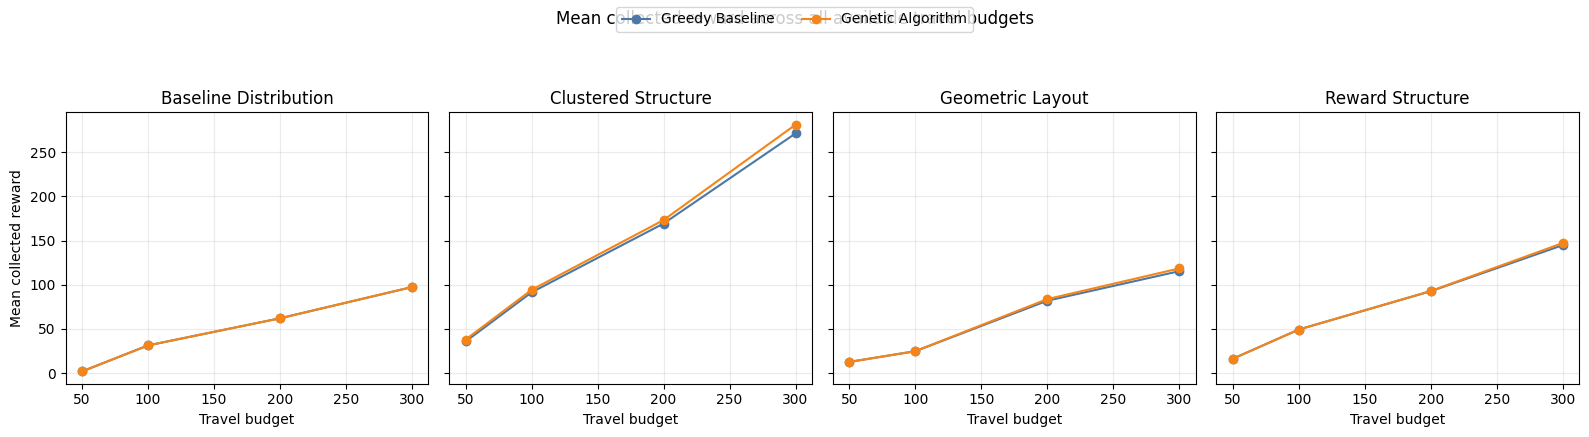

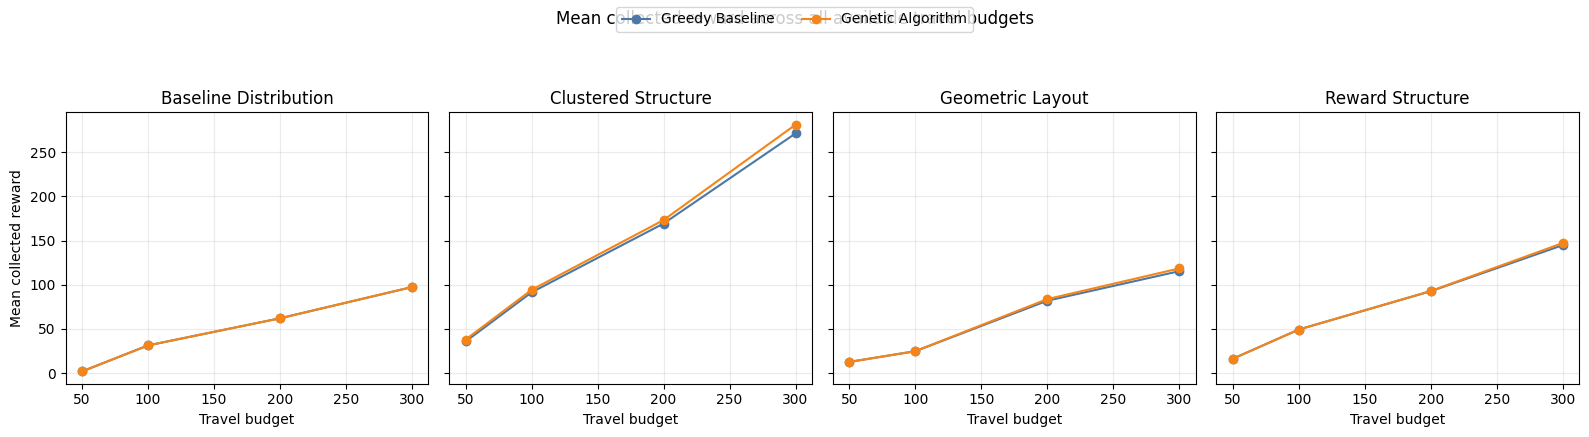

In [24]:
class_budget_summary = (
    complete_instances.groupby(['budget', 'scenario_class', 'class_order', 'approach_label'], as_index=False)
    .agg(mean_reward=('reward', 'mean'))
    .sort_values(['class_order', 'budget', 'approach_label'])
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for axis, scenario_class in zip(axes, SCENARIO_CLASSES):
    data = class_budget_summary[class_budget_summary.scenario_class == scenario_class]
    for approach in ['Greedy Baseline', 'Genetic Algorithm']:
        approach_data = data[data.approach_label == approach]
        axis.plot(approach_data.budget, approach_data.mean_reward, marker='o', label=approach, color=COLORS[approach])
    axis.set_title(scenario_class)
    axis.set_xlabel('Travel budget')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Mean collected reward')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Mean collected reward across all available travel budgets', y=1.08)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mean_reward_trend_all_budgets.png', dpi=200, bbox_inches='tight')
fig
